In [3]:
import pandas as pd
from os.path import expanduser as ospath
import seaborn as sns
from matplotlib import pyplot as plt

import numpy as np
import ruptures as rpt

from scipy.optimize import minimize


In [4]:
filepaths = [
    'Реология для обработки.xlsx'
]

In [5]:
def sigma_i(sigma_1, sigma_2):
    sigma_i = 1/(2**0.5) * (
        (sigma_1 - sigma_2) ** 2 + (sigma_2-sigma_2) ** 2 + (sigma_2-sigma_1) ** 2
    ) ** 0.5
    return sigma_i

In [6]:
def e_i(e_1, e_3):
    e_i = 2 ** 0.5 / 3 * (
    (e_1 - e_3) ** 2 + (e_3 - e_3) ** 2 + (e_3 - e_1) ** 2
    ) ** 0.5
    return e_i

In [7]:
def prepare_data(data):
    data.drop(index=[0,1], inplace=True)
    data.drop(columns=data.columns[0], axis=1, inplace=True)
    data.columns = ['time', 'sigma_2', 'sigma_1', 'e1', 'e3']
    for col in data.columns:
        data[col] = data[col].astype('float64')
    data['time'] = data['time'] / 24
    data['e_i'] = e_i(data['e1'], data['e3'])
    data['s_i'] = sigma_i(data['sigma_2'], data['sigma_1'])

In [8]:
def find_de_dt(data):
    s_int = data['s_i'].max()
    time = np.array(data['time'])
    e_i = np.array(data['e_i'])
    model = "l2"
    algo = rpt.Pelt(model=model, min_size=3, jump=1).fit(e_i)
    my_bkps = algo.predict(pen=0.0001)

    linear_section_start = my_bkps[0]
    x_linear = time[linear_section_start:].astype('float64')
    y_linear = e_i[linear_section_start:].astype('float64')
    try:
        coefficients = np.polyfit(x_linear, y_linear, 1)
        value = coefficients[0]
    except:
        value = None
    return value, s_int

In [9]:
def analyze_all_data(file_paths):
    de_dt = []
    s_i =[]
    s_1 = []
    s_2 = []
    for path in file_paths:
        data = pd.read_excel(ospath(path), None)
        for table in data:
            prepare_data(data[table])
            s_1.append(data[table]['sigma_1'].max())
            s_2.append(data[table]['sigma_2'].max())
            de_value, s_int_value = find_de_dt(data[table])
            de_dt.append(de_value)
            s_i.append(s_int_value)
        print(path, '- ✅')
    return de_dt, s_i, s_1, s_2

In [10]:
de_dt, s_i, s_1, s_2 = analyze_all_data(filepaths)

Реология для обработки.xlsx - ✅


In [11]:
de_si = pd.DataFrame()
de_si['s_i'] = s_i
de_si['de_dt'] = de_dt

In [12]:
len(de_dt)

17

In [13]:
de_si = de_si.dropna().sort_values(by='s_i').reset_index(drop=True)

de_si['s_i'] = de_si['s_i'].apply(round)
grouped = de_si.groupby(['s_i']).mean()

In [14]:
grouped = grouped.reset_index()
grouped

,s_i,de_dt
0,3,0.000635
1,4,0.002600
2,5,0.009416
3,6,0.028595
4,7,0.013648
5,8,0.086085


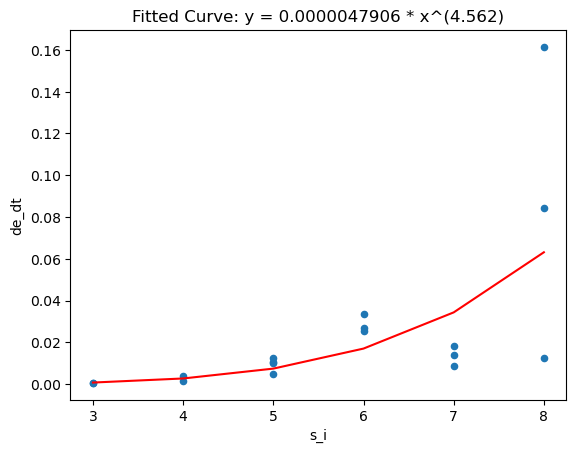

In [15]:
de_si.plot(x ='s_i', y = 'de_dt', kind = 'scatter')
log_x = np.log(grouped['s_i'])
log_y = np.log(grouped['de_dt'])

coefficients = np.polyfit(log_x, log_y, 1)

a = np.exp(coefficients[1])
n = coefficients[0]

x = np.array(grouped['s_i'])
y = a * x ** n
plt.plot(x, y, 'r-', label='Fitted Curve')
plt.title('Fitted Curve: y = {:.10f} * x^({:.3f})'.format(a, n))

plt.show()


In [16]:
print(a, n)

4.790584176199306e-06 4.561740197296631


0
1
2


/var/folders/gb/njsrwj253nd14gv4htvqf5pc0000gn/T/ipykernel_61411/1821149587.py:3: RuntimeWarning: divide by zero encountered in power
  y = A / (m + 1) * sig_int ** n * x ** (m + 1)
/Users/dmitry/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/var/folders/gb/njsrwj253nd14gv4htvqf5pc0000gn/T/ipykernel_61411/1821149587.py:3: RuntimeWarning: divide by zero encountered in power
  y = A / (m + 1) * sig_int ** n * x ** (m + 1)


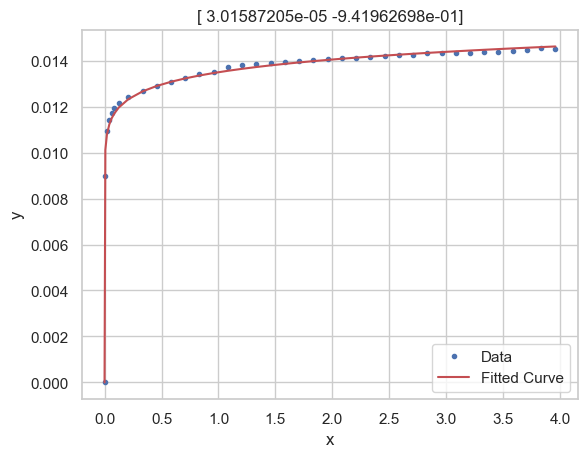

0


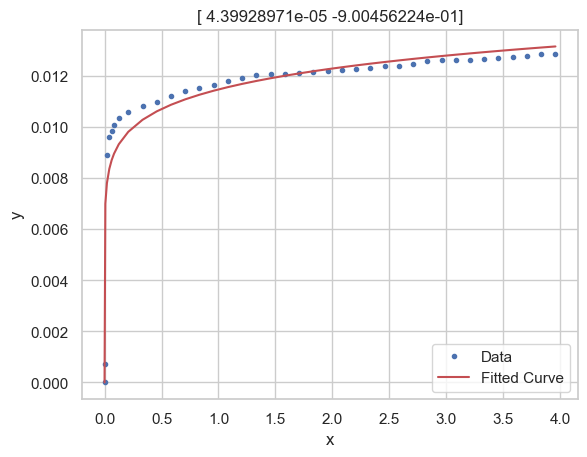

0


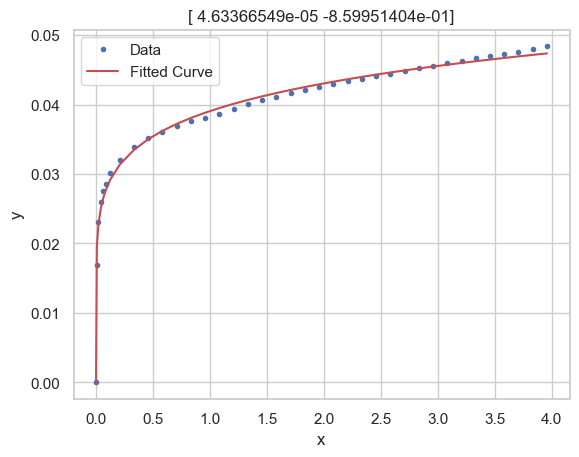

0


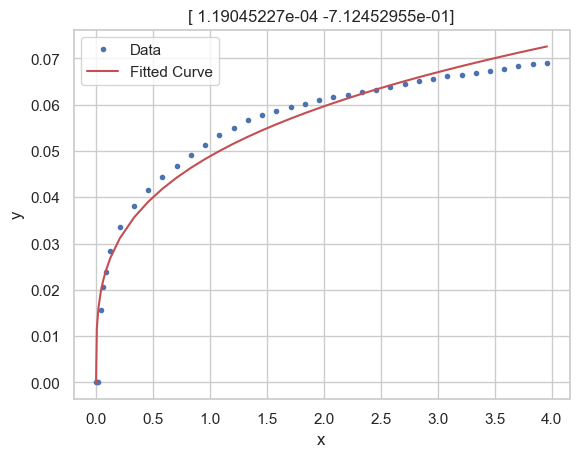

0
1


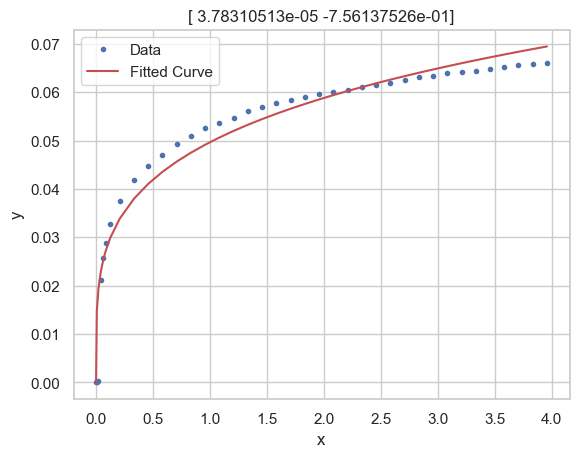

0
1
2


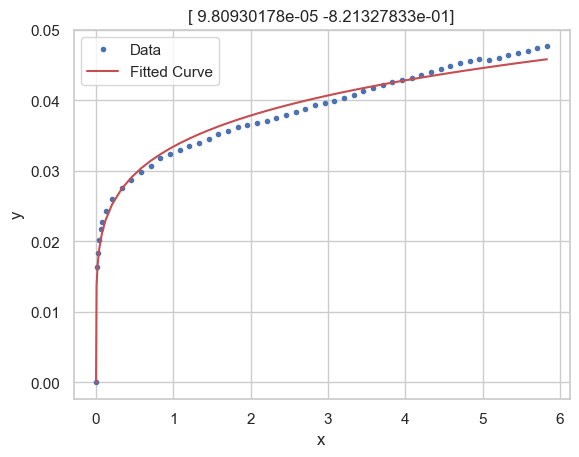

0
1
2
3


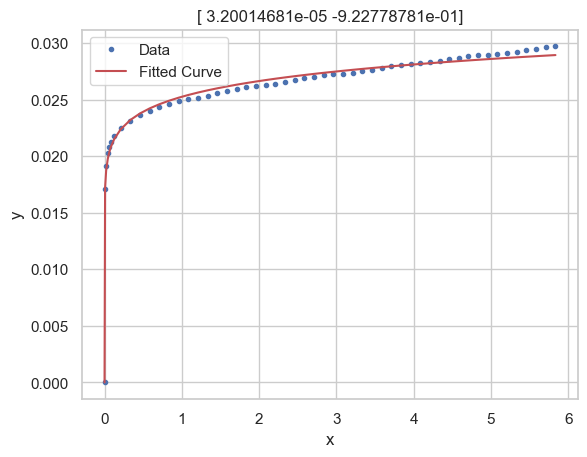

0


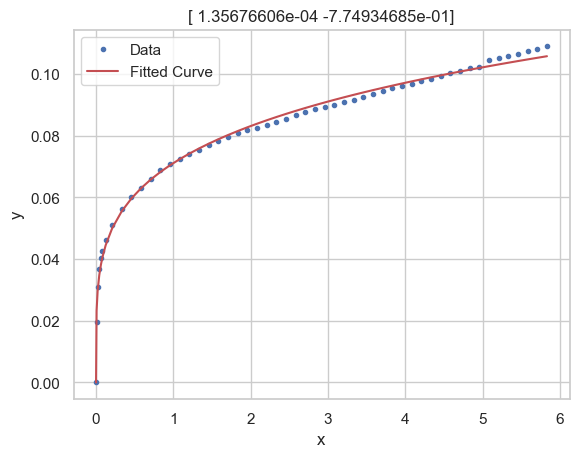

0


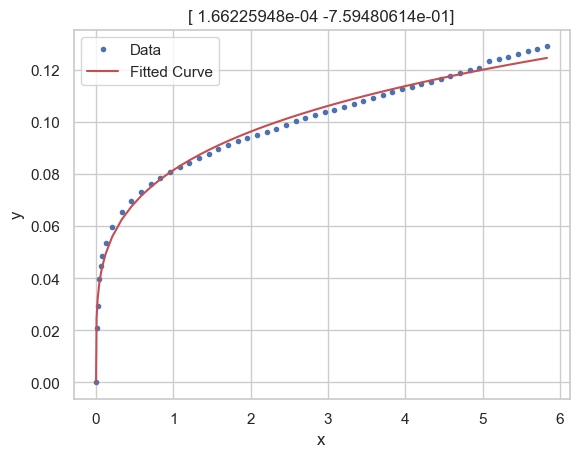

0
1
2


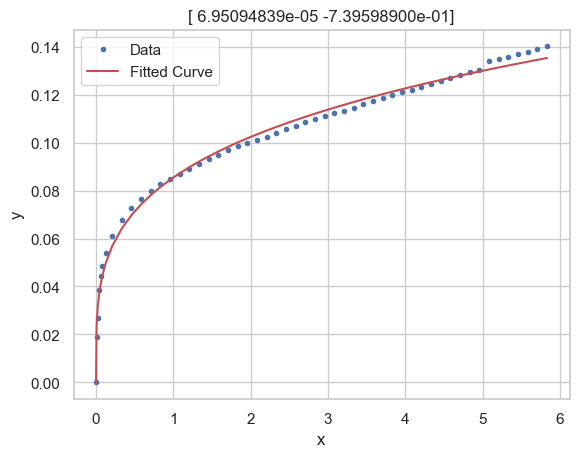

0
1
2


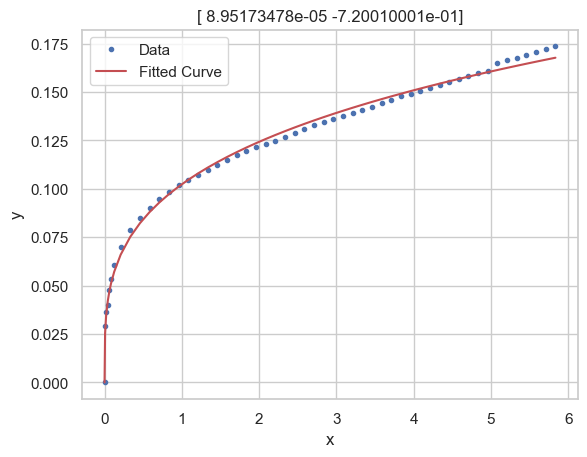

0
1
2


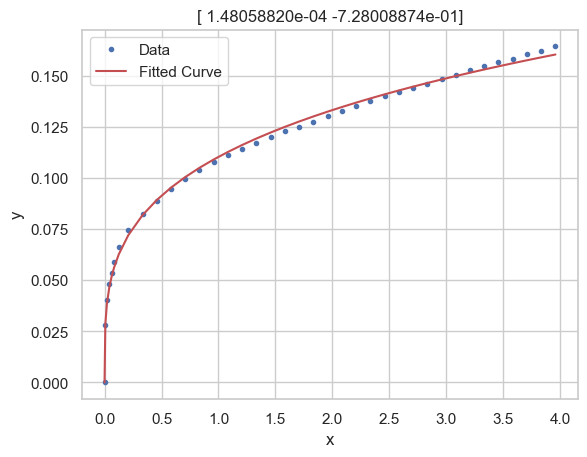

0
1


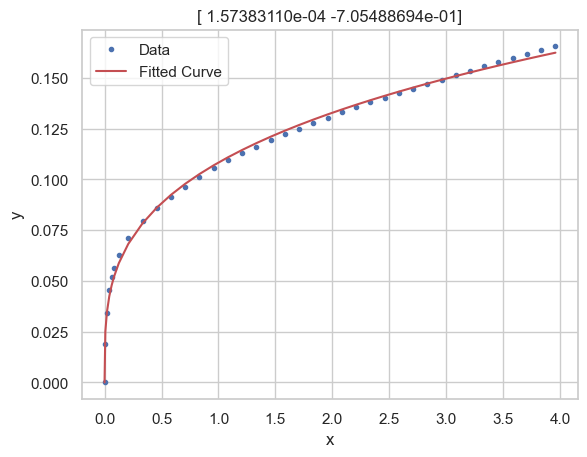

0


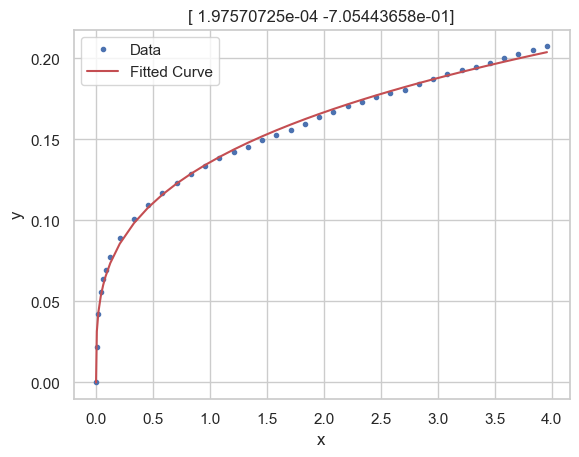

0


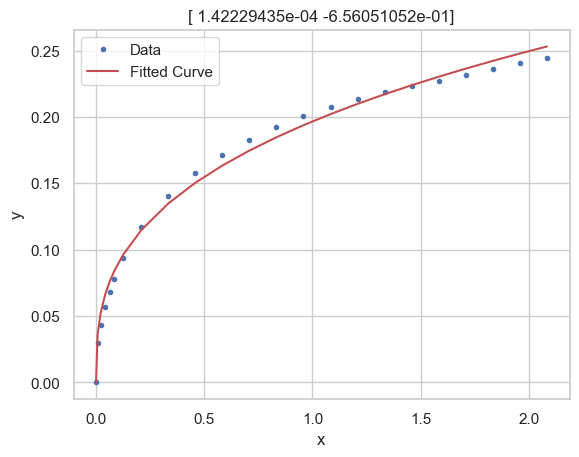

0


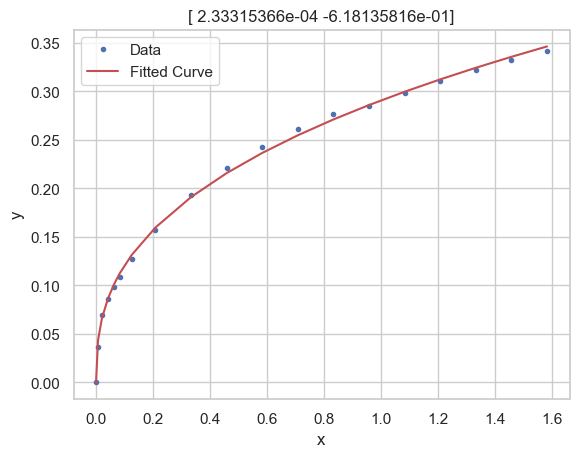

0


/var/folders/gb/njsrwj253nd14gv4htvqf5pc0000gn/T/ipykernel_61411/1821149587.py:3: RuntimeWarning: divide by zero encountered in power
  y = A / (m + 1) * sig_int ** n * x ** (m + 1)
/Users/dmitry/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


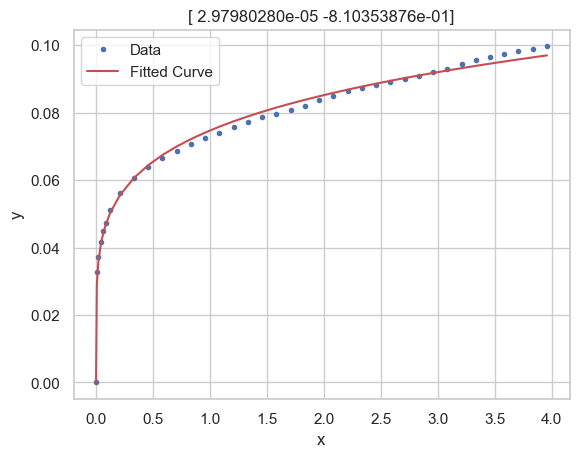

In [27]:
def custom_equation(x, A, m):
    n = 2.964428890433537
    y = A / (m + 1) * sig_int ** n * x ** (m + 1)
    return y

def objective_function(parameters, x, y):
    predicted_values = custom_equation(x, *parameters)
    
    residuals = predicted_values - y
    
    objective = np.sum(residuals**2)
    
    return objective


def optimize_curve(params):
    initial_guess = params

    result = minimize(objective_function, initial_guess, args=(x, y))

    optimal_parameters = result.x

    return optimal_parameters
        
        
coeff_a = []
coeff_m = []
for path in filepaths:
    data = pd.read_excel(ospath(path), None)
    for table in data:
        prepare_data(data[table])
        x = np.array(data[table]['time'])
        sig_int = data[table]['s_i'].max()
        y = np.array(data[table]['e_i'])
        
        optimal_parameters = [a, -0.5]
        
        new_params = optimize_curve(optimal_parameters)
        i = 0
        while all(x != y for x, y in zip(optimal_parameters, new_params)):
            print(i)
            optimal_parameters = new_params.copy()
            new_params = optimize_curve(optimal_parameters)
            i += 1
        else:
            optimal_parameters = new_params
            
        coeff_a.append(optimal_parameters[0])
        coeff_m.append(optimal_parameters[1])
        

        fitted_curve = custom_equation(x, *optimal_parameters)

        plt.plot(x, y, 'b.', label='Data')
        plt.plot(x, fitted_curve, 'r-', label='Fitted Curve')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'{optimal_parameters}')
        plt.legend()
        plt.show()

In [28]:
a = pd.Series(coeff_a).mean()
m = pd.Series(coeff_m).mean()

In [29]:
print(f'A = {a}\nn = {n}\nm = {m}')

A = 0.00010451434744995582
n = 4.561740197296631
m = -0.7725043288788179


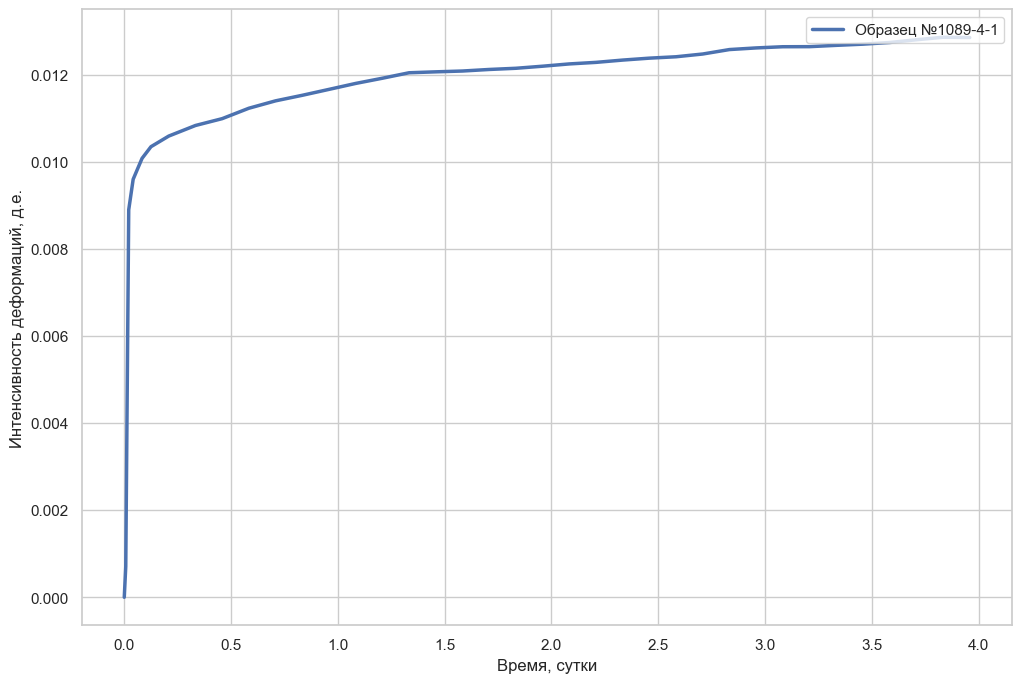

In [30]:
name_list=[]
plt.figure(figsize=(12,8))
for path in filepaths:
    data = pd.read_excel(ospath(path), None)
    names = list(data.keys())
    experiment = names[1]
    name_list.append(experiment)
    prepare_data(data[experiment])
    ax = sns.lineplot(data=data[experiment], x='time', y ='e_i', palette="tab10", linewidth=2.5)
    sns.set_theme(style="whitegrid")
    ax.set_xlabel('Время, сутки')
    ax.set_ylabel('Интенсивность деформаций, д.е.')
    ax.set_label = experiment
ax.legend(name_list, loc=1)
plt.savefig('интенсивность деформаций.png', dpi=600)
plt.show()


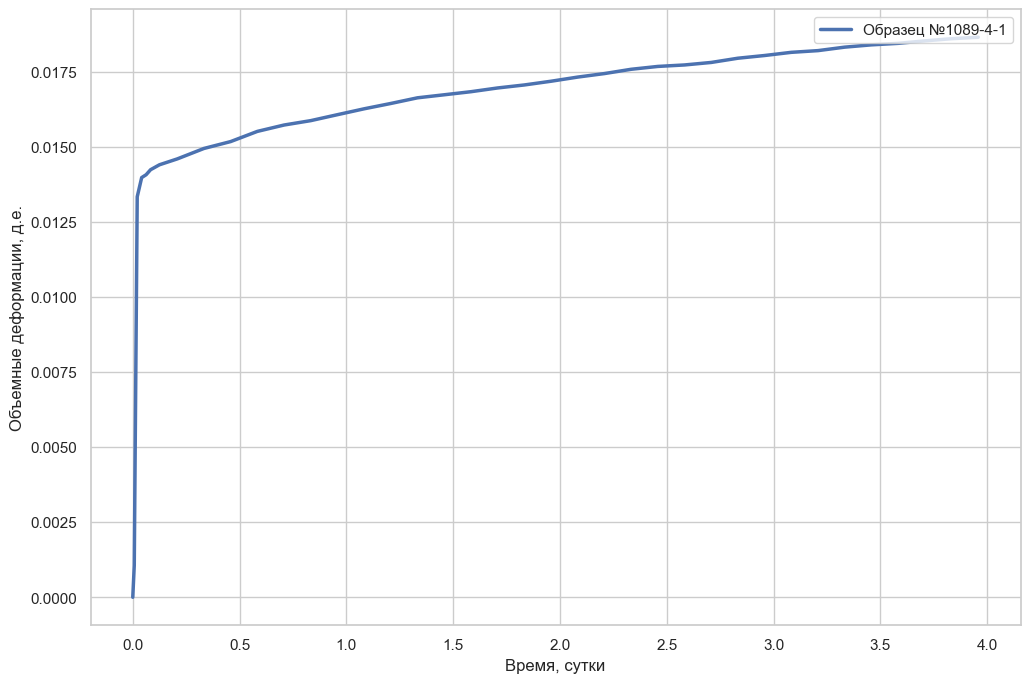

In [21]:
name_list=[]
plt.figure(figsize=(12,8))
for path in filepaths:
    data = pd.read_excel(ospath(path), None)
    names = list(data.keys())
    experiment = names[1]
    name_list.append(experiment)
    prepare_data(data[experiment])
    data[experiment]['e_v'] = data[experiment]['e1'] + 2 * data[experiment]['e3']
    ax = sns.lineplot(data=data[experiment], x='time', y ='e_v', palette="tab10", linewidth=2.5)
    sns.set_theme(style="whitegrid")
    ax.set_xlabel('Время, сутки')
    ax.set_ylabel('Объемные деформации, д.е.')
    ax.set_label = experiment
ax.legend(name_list, loc=1)
plt.savefig('объемные деформации.png', dpi=600)
plt.show()
